In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/female-data/female_data.csv
/kaggle/input/male-data/male_data.csv


Splitting dataset to X and y: Female and Male

In [2]:
import pandas as pd

female_data = pd.read_csv('/kaggle/input/female-data/female_data.csv')
male_data = pd.read_csv('/kaggle/input/male-data/male_data.csv')

features_not_chosen = ['Alopecia', 'Glucose', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Diabetes_Status', 'Family_Diabetes', 'Smoking', 'Alcohol', 'RegularMedicine', 'JunkFood', 'Stress', 'Pdiabetes', 'UriationFreq', 'Diabetic', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'unexplained prenetal loss', 'Large Child or Birth Default', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'Itching', 'Irritability', 'muscle stiffness', 'Patient_ID']
X_female = female_data.drop(features_not_chosen, axis=1)
y_female = female_data['Diabetes_Status']

from sklearn.model_selection import train_test_split

# Split the data (70% train, 30% test)
X_train_female, X_test_female, y_train_female, y_test_female = train_test_split(X_female, y_female, test_size=0.3, random_state=42)

# apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_female_smote, y_train_female_smote = smote.fit_resample(X_train_female, y_train_female)

In [3]:
features_not_chosen = ['Alopecia', 'Diabetes_Status', 'Family_Diabetes', 'Smoking', 'Alcohol', 'RegularMedicine', 'JunkFood', 'Stress', 'Pdiabetes', 'UriationFreq', 'Diabetic', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'Itching', 'Irritability', 'muscle stiffness', 'Patient_ID']
X_male = male_data.drop(features_not_chosen, axis=1)
y_male = male_data['Diabetes_Status']



# Split the data (70% train, 30% test)
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(X_male, y_male, test_size=0.3, random_state=42)

X_train_male_smote, y_train_male_smote = smote.fit_resample(X_train_male, y_train_male)

In [4]:
print(X_train_male_smote.columns)
print(X_train_female_smote.columns)

Index(['Age', 'HighBP', 'PhysicallyActive', 'BMI', 'Sleep', 'SoundSleep',
       'BPLevel', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Education', 'Income',
       'Polyuria', 'visual blurring', 'delayed healing', 'partial paresis',
       'Obesity'],
      dtype='object')
Index(['Age', 'HighBP', 'PhysicallyActive', 'BMI', 'Sleep', 'SoundSleep',
       'BPLevel', 'Pregnancies', 'GenHlth', 'PhysHlth', 'DiffWalk',
       'Education', 'Income', 'Gestation in previous Pregnancy', 'PCOS',
       'Sedentary Lifestyle', 'Polyuria', 'visual blurring', 'delayed healing',
       'partial paresis', 'Obesity', 'Pregnant'],
      dtype='object')


Model Training Female

Training XGBoost...
Accuracy for XGBoost on training set: 0.86
Log Loss for XGBoost on training set: 0.35
Training Random Forest...


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy for Random Forest on training set: 0.55
Log Loss for Random Forest on training set: 1.03


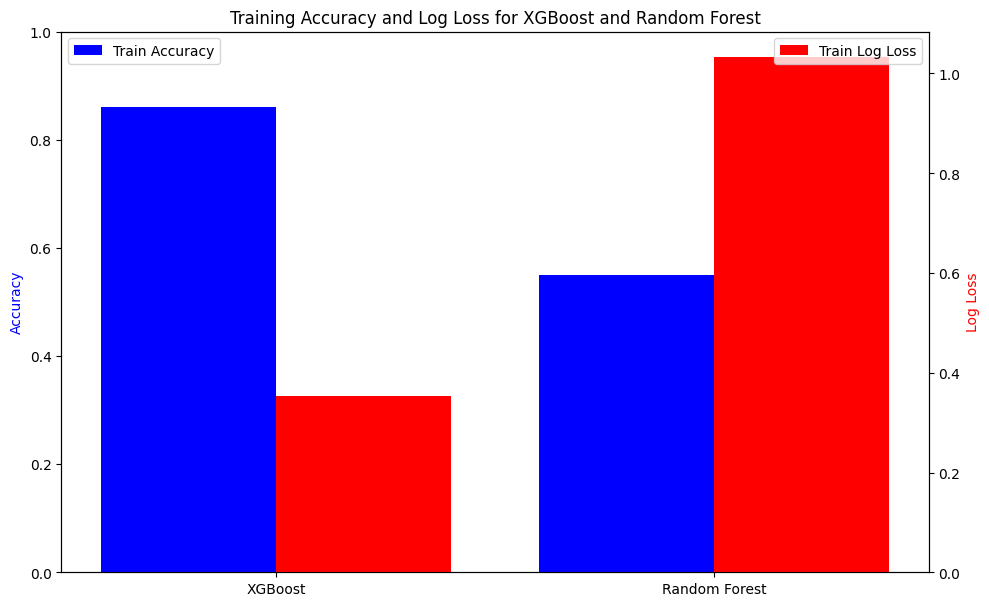

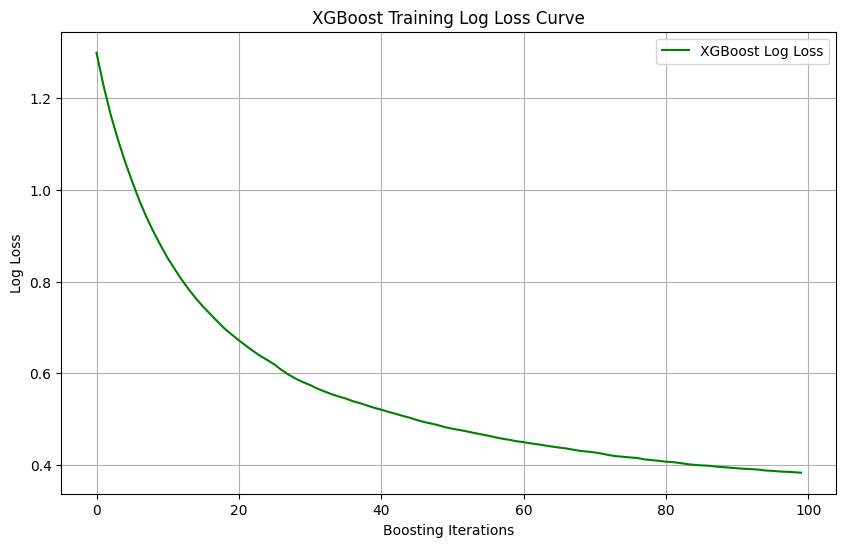

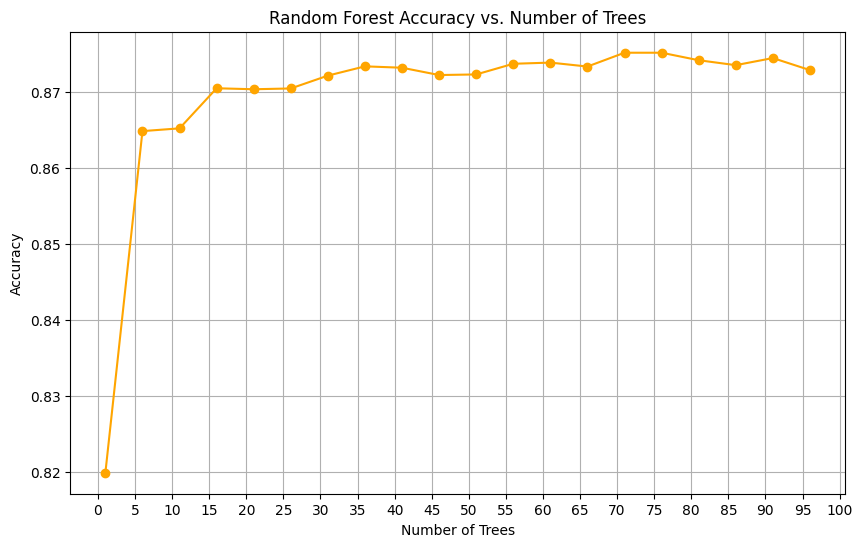

Selected Features: ['Pregnant' 'GenHlth' 'HighBP' 'Gestation in previous Pregnancy' 'Income'
 'Education' 'BMI' 'Age' 'PhysHlth' 'PhysicallyActive' 'DiffWalk' 'PCOS'
 'Pregnancies' 'SoundSleep' 'delayed healing' 'BPLevel' 'Sleep'
 'Sedentary Lifestyle' 'visual blurring']
Retraining XGBoost with selected features...
Accuracy for XGBoost on retrained model: 0.86
Retraining Random Forest with selected features...
Accuracy for Random Forest on retrained model: 1.00


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Load your dataset here
# X_train_female_smote, y_train_female_smote, X_test_female, y_test_female = ...

# Scale data for both models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_female_smote)
X_test_scaled = scaler.transform(X_test_female)

# Define models to evaluate
models = {
    'XGBoost': XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, n_estimators=100, learning_rate=0.1),
    'Random Forest': RandomForestClassifier(),
}

# To store metrics for plotting
train_accuracy = {}
train_loss = {}
feature_importances = {}
accuracy_curves = {}
random_forest_accuracy_curve = []

# Initial training and evaluation
for name, model in models.items():
    print(f'Training {name}...')
    X_train = X_train_scaled
    X_test = X_test_scaled
    # Choose scaled or unscaled data depending on the model
    if name == 'XGBoost':
        # For XGBoost, keep track of accuracy at each iteration
        model.fit(X_train, y_train_female_smote, eval_set=[(X_test, y_test_female)], verbose=False)
        accuracy_curve = model.evals_result()['validation_0']['mlogloss']
        accuracy_curves[name] = accuracy_curve
    else:
        # For Random Forest, vary the number of trees and store accuracy
        for n_trees in range(1, 101, 5):  # Change step as needed
            model = RandomForestClassifier(n_estimators=n_trees)
            model.fit(X_train_female_smote, y_train_female_smote)
            y_test_pred = model.predict(X_test_female)
            train_acc = accuracy_score(y_test_female, y_test_pred)
            random_forest_accuracy_curve.append((n_trees, train_acc))

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # For log_loss, use probability predictions if available
    if hasattr(model, 'predict_proba'):
        y_train_prob = model.predict_proba(X_train)
        train_loss_val = log_loss(y_train_female_smote, y_train_prob)
    else:
        train_loss_val = np.nan
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train_female_smote, y_train_pred)
    
    train_accuracy[name] = train_acc
    train_loss[name] = train_loss_val
    
    # Collect feature importances
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances[name] = np.abs(model.coef_[0])  # For linear models

    print(f'Accuracy for {name} on training set: {train_acc:.2f}')
    if not np.isnan(train_loss_val):
        print(f'Log Loss for {name} on training set: {train_loss_val:.2f}')
    else:
        print(f'Log Loss for {name} on training set: Not Available (No predict_proba)')

# Plotting accuracy and loss
labels = list(train_accuracy.keys())
accuracy_values = list(train_accuracy.values())
loss_values = list(train_loss.values())

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot accuracy
ax1.bar(x - 0.2, accuracy_values, 0.4, label='Train Accuracy', color='b')
ax1.set_ylabel('Accuracy', color='b')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# Create a second y-axis to plot loss
ax2 = ax1.twinx()
ax2.bar(x + 0.2, loss_values, 0.4, label='Train Log Loss', color='r')
ax2.set_ylabel('Log Loss', color='r')

fig.tight_layout()
plt.title('Training Accuracy and Log Loss for XGBoost and Random Forest')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.savefig('model_accuracies_female.png')
plt.show()

# Plot Accuracy Curves for XGBoost
if 'XGBoost' in accuracy_curves:
    plt.figure(figsize=(10, 6))
    plt.plot(accuracy_curves['XGBoost'], label='XGBoost Log Loss', color='g')
    plt.title('XGBoost Training Log Loss Curve')
    plt.xlabel('Boosting Iterations')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid()
    plt.savefig('xgboost_accuracy_curve_female.png')
    plt.show()

# Plotting Random Forest accuracy curve
n_trees, acc_values = zip(*random_forest_accuracy_curve)
plt.figure(figsize=(10, 6))
plt.plot(n_trees, acc_values, marker='o', color='orange')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.xticks(range(0, 101, 5))  # Adjust x-ticks as needed
plt.grid()
plt.savefig('random_forest_accuracy_curve_female.png')
plt.show()

# Feature Importance Analysis
# Average feature importances
if feature_importances:
    average_importance = np.mean(np.array(list(feature_importances.values())), axis=0)
    feature_names = X_train_female_smote.columns  # Assuming X_train_female_smote is a DataFrame
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': average_importance})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # Select features above a certain importance threshold (e.g., top 10 features)
    selected_features = feature_importance_df[feature_importance_df['importance'] > 0.01]['feature'].values

    print("Selected Features:", selected_features)

    # Update the training and test set with selected features
    X_train_female_smote_selected = X_train_female_smote[selected_features]
    X_test_female_selected = X_test_female[selected_features]
    
    X_train_scaled = scaler.fit_transform(X_train_female_smote_selected)
    X_test_scaled = scaler.transform(X_test_female_selected)

    # Optionally, retrain models with the selected features
    for name, model in models.items():
        print(f'Retraining {name} with selected features...')
        
        model.fit(X_train_scaled, y_train_female_smote)
        
        # Predictions and evaluation can be repeated here if needed
        y_train_pred_selected = model.predict(X_train_scaled)
        y_test_pred_selected = model.predict(X_test_scaled)
        
        # Evaluate again
        train_acc_selected = accuracy_score(y_train_female_smote, y_train_pred_selected)
        print(f'Accuracy for {name} on retrained model: {train_acc_selected:.2f}')


Model Training Male

Training XGBoost...
Accuracy for XGBoost on training set: 0.88
Log Loss for XGBoost on training set: 0.35
Training Random Forest...


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without

Accuracy for Random Forest on training set: 0.99
Log Loss for Random Forest on training set: 0.05


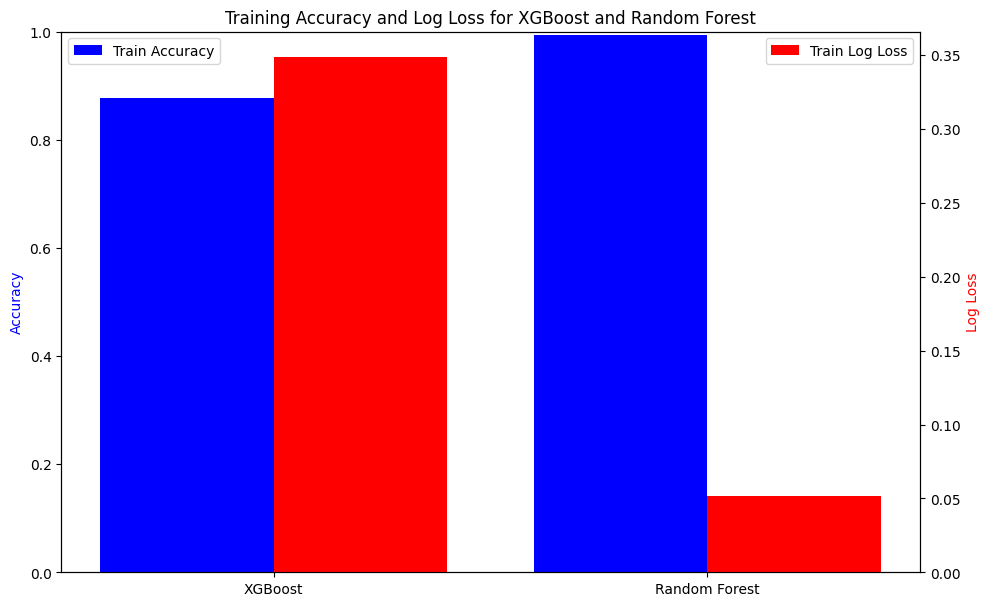

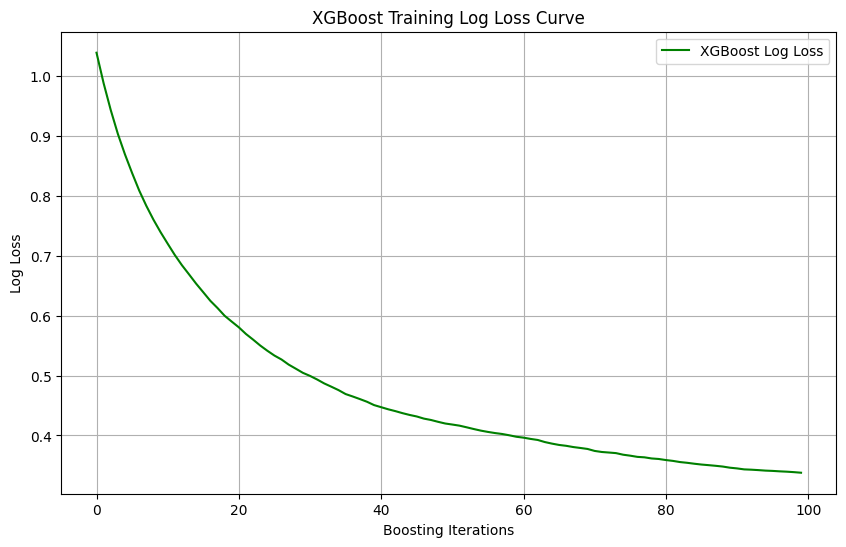

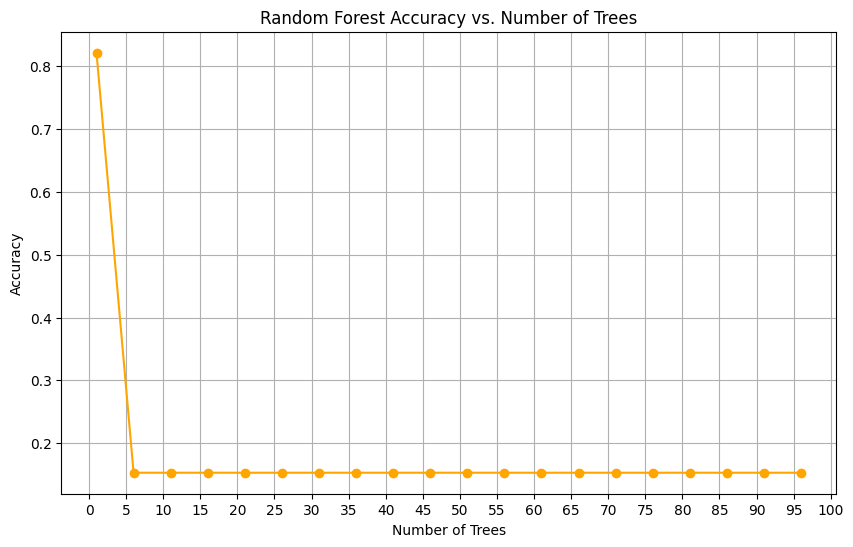

Selected Features: ['HighBP' 'BMI' 'GenHlth' 'SoundSleep' 'Polyuria' 'Age' 'Education'
 'Income' 'BPLevel' 'PhysicallyActive' 'DiffWalk' 'Sleep' 'PhysHlth'
 'delayed healing' 'partial paresis']
Retraining XGBoost with selected features...
Accuracy for XGBoost on retrained model: 0.88
Retraining Random Forest with selected features...
Accuracy for Random Forest on retrained model: 0.99


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Load your dataset here
# X_train_female_smote, y_train_female_smote, X_test_female, y_test_female = ...

# Scale data for both models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_male_smote)
X_test_scaled = scaler.transform(X_test_male)

# Define models to evaluate
models = {
    'XGBoost': XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, n_estimators=100, learning_rate=0.1),
    'Random Forest': RandomForestClassifier(),
}

# To store metrics for plotting
train_accuracy = {}
train_loss = {}
feature_importances = {}
accuracy_curves = {}
random_forest_accuracy_curve = []

# Initial training and evaluation
for name, model in models.items():
    print(f'Training {name}...')
    X_train = X_train_scaled
    X_test = X_test_scaled
    # Choose scaled or unscaled data depending on the model
    if name == 'XGBoost':
        # For XGBoost, keep track of accuracy at each iteration
        model.fit(X_train, y_train_male_smote, eval_set=[(X_test, y_test_male)], verbose=False)
        accuracy_curve = model.evals_result()['validation_0']['mlogloss']
        accuracy_curves[name] = accuracy_curve
    else:
        # For Random Forest, vary the number of trees and store accuracy
        for n_trees in range(1, 101, 5):  # Change step as needed
            model = RandomForestClassifier(n_estimators=n_trees)
            model.fit(X_train, y_train_male_smote)
            y_test_pred = model.predict(X_test_male)
            train_acc = accuracy_score(y_test_male, y_test_pred)
            random_forest_accuracy_curve.append((n_trees, train_acc))

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # For log_loss, use probability predictions if available
    if hasattr(model, 'predict_proba'):
        y_train_prob = model.predict_proba(X_train)
        train_loss_val = log_loss(y_train_male_smote, y_train_prob)
    else:
        train_loss_val = np.nan
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train_male_smote, y_train_pred)
    
    train_accuracy[name] = train_acc
    train_loss[name] = train_loss_val
    
    # Collect feature importances
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances[name] = np.abs(model.coef_[0])  # For linear models

    print(f'Accuracy for {name} on training set: {train_acc:.2f}')
    if not np.isnan(train_loss_val):
        print(f'Log Loss for {name} on training set: {train_loss_val:.2f}')
    else:
        print(f'Log Loss for {name} on training set: Not Available (No predict_proba)')

# Plotting accuracy and loss
labels = list(train_accuracy.keys())
accuracy_values = list(train_accuracy.values())
loss_values = list(train_loss.values())

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot accuracy
ax1.bar(x - 0.2, accuracy_values, 0.4, label='Train Accuracy', color='b')
ax1.set_ylabel('Accuracy', color='b')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# Create a second y-axis to plot loss
ax2 = ax1.twinx()
ax2.bar(x + 0.2, loss_values, 0.4, label='Train Log Loss', color='r')
ax2.set_ylabel('Log Loss', color='r')

fig.tight_layout()
plt.title('Training Accuracy and Log Loss for XGBoost and Random Forest')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.savefig('model_accuracies_male.png')
plt.show()

# Plot Accuracy Curves for XGBoost
if 'XGBoost' in accuracy_curves:
    plt.figure(figsize=(10, 6))
    plt.plot(accuracy_curves['XGBoost'], label='XGBoost Log Loss', color='g')
    plt.title('XGBoost Training Log Loss Curve')
    plt.xlabel('Boosting Iterations')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid()
    plt.savefig('xgboost_accuracy_curve_male.png')
    plt.show()

# Plotting Random Forest accuracy curve
n_trees, acc_values = zip(*random_forest_accuracy_curve)
plt.figure(figsize=(10, 6))
plt.plot(n_trees, acc_values, marker='o', color='orange')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.xticks(range(0, 101, 5))  # Adjust x-ticks as needed
plt.grid()
plt.savefig('random_forest_accuracy_curve_male.png')
plt.show()

# Feature Importance Analysis
# Average feature importances
if feature_importances:
    average_importance = np.mean(np.array(list(feature_importances.values())), axis=0)
    feature_names = X_train_male_smote.columns  # Assuming X_male is a DataFrame
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': average_importance})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # Select features above a certain importance threshold (e.g., top 10 features)
    selected_features = feature_importance_df[feature_importance_df['importance'] > 0.01]['feature'].values

    print("Selected Features:", selected_features)

    # Update the training and test set with selected features
    X_train_male_smote_selected = X_train_male_smote[selected_features]
    X_test_male_selected = X_test_male[selected_features]
    
    X_train_scaled = scaler.fit_transform(X_train_male_smote_selected)
    X_test_scaled = scaler.transform(X_test_male_selected)

    # Optionally, retrain models with the selected features
    for name, model in models.items():
        print(f'Retraining {name} with selected features...')
        
        model.fit(X_train_scaled, y_train_male_smote)
        
        # Predictions and evaluation can be repeated here if needed
        y_train_pred_selected = model.predict(X_train_scaled)
        y_test_pred_selected = model.predict(X_test_scaled)
        
        # Evaluate again
        train_acc_selected = accuracy_score(y_train_male_smote, y_train_pred_selected)
        print(f'Accuracy for {name} on retrained model: {train_acc_selected:.2f}')
